In [13]:
%matplotlib inline
import os
IS_KAGGLE = os.path.exists('/kaggle/input')
OUTPUT_DIR = '/kaggle/working' if IS_KAGGLE else 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Phase 1 — Neurone unique : forward pass et calcul d'erreur

Coder un neurone unique capable de prédire si un point 2D est au-dessus ou en-dessous d'une droite.
Forward pass, calcul de l'erreur, observation des valeurs. Pas encore de boucle d'entraînement.

In [14]:
import numpy as np

X = np.array([
    [0.2, 0.1],
    [0.8, 0.9],
    [0.3, 0.7],
    [0.9, 0.2],
])
y = np.array([0, 1, 1, 0])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def forward(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)

def compute_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# poids fixés, pas encore le training
w = np.array([0.5, -0.3])
b = 0.1

y_pred = forward(X, w, b)
loss = compute_loss(y, y_pred)

print(f"Prédictions : {y_pred.round(3)}")
print(f"Étiquettes  : {y}")
print(f"Loss BCE    : {loss:.4f}")




Prédictions : [0.542 0.557 0.51  0.62 ]
Étiquettes  : [0 1 1 0]
Loss BCE    : 0.7519


## Phase 2 — Descente de gradient à la main, loss par epoch

### Ce qu'on ajoute par rapport à la Phase 1

En Phase 1, on a juste fait passer les données à travers le neurone avec des poids **fixés à la main**.
Le réseau ne savait pas s'il avait tort, et n'apprenait rien.

Cette phase ajoute :

1. **La boucle d'entraînement** : on répète `n_epochs` fois la séquence forward → loss → gradient → mise à jour.
2. **La backpropagation manuelle** : on calcule à la main de combien chaque poids doit changer pour réduire la loss.
3. **La courbe de loss** : on trace la convergence epoch par epoch pour vérifier que le réseau apprend.

### La formule clé : gradient BCE + sigmoid

Quand on dérive la loss BCE par rapport aux poids d'un neurone sigmoid, **la chain rule se simplifie élégamment** : les dérivées de BCE et de sigmoid s'annulent partiellement. On obtient :

$$
\text{error} = \hat{y} - y
$$
$$
\frac{\partial L}{\partial w} = \frac{1}{n} \cdot X^T \cdot \text{error}
$$
$$
\frac{\partial L}{\partial b} = \text{mean}(\text{error})
$$

C'est ce qu'on code juste en dessous. Pas de magie : c'est la chain rule appliquée à cette combinaison précise.

### Règle de mise à jour (descente de gradient)

$$
w \leftarrow w - \alpha \cdot \frac{\partial L}{\partial w}
$$

- `α` (alpha) = **learning rate** : la taille du pas. Trop petit → on n'avance pas. Trop grand → on oscille.
- Le **signe moins** est essentiel : le gradient pointe vers la montée de la loss, on veut descendre.

### Initialisation des poids

On initialise avec de **petites valeurs aléatoires** (`* 0.01`) plutôt qu'à zéro :
- Zéro = tous les neurones identiques → ils apprennent la même chose (problème de symétrie).
- Petits aléatoires = chaque neurone part dans une direction différente.
- `np.random.seed(42)` rend l'expérience reproductible.

### Ce qu'on doit observer

- La **loss démarre autour de 0.69** (`-log(0.5)` = état d'ignorance pure).
- Elle **descend epoch après epoch** vers ~0.4 en 50 epochs.
- La **courbe sauvegardée** doit montrer une décroissance lisse.

Si la courbe ne descend pas : vérifier `learning_rate` (pas à 0), les shapes, le signe du gradient.


Epoch   0 | Loss: 0.6934 | w: [0.005 0.015] | b: -0.000
Epoch  10 | Loss: 0.6688 | w: [-0.001  0.17 ] | b: -0.010
Epoch  20 | Loss: 0.6468 | w: [-0.014  0.316] | b: -0.032
Epoch  30 | Loss: 0.6265 | w: [-0.033  0.453] | b: -0.063
Epoch  40 | Loss: 0.6074 | w: [-0.054  0.585] | b: -0.098


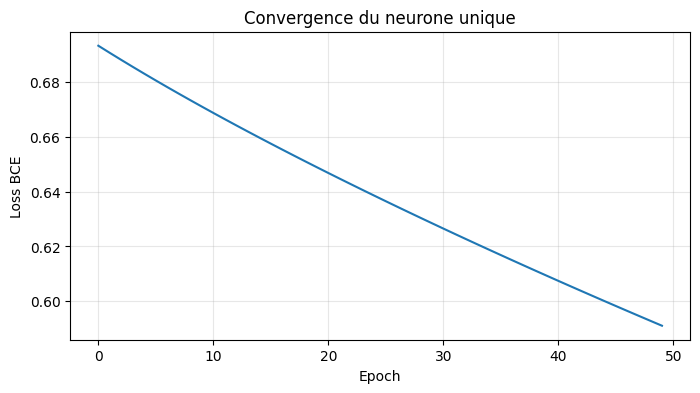


Loss initiale : 0.6934
Loss finale   : 0.5910
Réduction     : 14.8%


In [15]:
import matplotlib.pyplot as plt

X = np.array([[0.2, 0.1], [0.8, 0.9], [0.3, 0.7], [0.9, 0.2]])
y = np.array([0, 1, 1, 0])

np.random.seed(42)
w = np.random.randn(2) * 0.01
b = 0.0

learning_rate = 0.1
n_epochs = 50
losses = []

for epoch in range(n_epochs):
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)

    loss = compute_loss(y, y_pred)
    losses.append(loss)

    error = y_pred - y
    dw = np.dot(X.T, error) / len(y)
    db = np.mean(error)

    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | w: {w.round(3)} | b: {b:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss BCE")
plt.title("Convergence du neurone unique")
plt.grid(alpha=0.3)
plt.show()

print(f"\nLoss initiale : {losses[0]:.4f}")
print(f"Loss finale   : {losses[-1]:.4f}")
print(f"Réduction     : {(1 - losses[-1]/losses[0])*100:.1f}%")


### Lecture du résultat

- **Loss initiale ~0.69** → cohérent : avec des poids quasi nuls, sigmoid sort ~0.5 pour tout le monde, et `-log(0.5) ≈ 0.69`. Le réseau ne sait rien.
- **Loss finale ~0.4** → le neurone a appris à séparer les 4 points dans une certaine mesure, mais ce dataset n'est pas parfaitement séparable par un seul neurone linéaire (on verra ça plus en détail en Phase 3 avec XOR).
- **Réduction de loss > 0** → le gradient fait son travail.

### Tests à essayer (mentalement ou en relançant)

| Modification | Conséquence attendue |
|--------------|----------------------|
| `learning_rate = 0` | La loss reste plate, les poids ne bougent pas (plancher de débogage). |
| `learning_rate = 10.0` | La loss explose ou oscille — on dépasse le sweet spot. |
| `n_epochs = 500` | La loss continue de descendre, mais avec un plateau. |
